In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/dummy_dataset_employability.xlsx")

df.head()

,Tahun Lulus,Rumpun Jurusan,Jenjang Pendidikan,Kategori IPK,Lama Masa Studi,Pernah Magang,Memiliki Sertifikasi,Memiliki Prestasi,Aktif Organisasi,Jenis Organisasi,Jabatan Organisasi,Tingkat Keaktifan Organisasi (1-5),Jumlah Organisasi,Status Pekerjaan,Waktu Tunggu Kerja,Kesesuaian Pekerjaan,Kisaran Gaji
0,2025,Humaniora,D3,3.00 - 3.25,< 4 tahun,Ya,Tidak,Tidak,Tidak,Tidak mengikuti organisasi,Tidak pernah mengikuti organisasi,1,0,Sudah bekerja,3 - 6 bulan,Sesuai,< Rp3.000.000
1,2018,Komputer/TI,S1,3.26 - 3.50,< 4 tahun,Tidak,Tidak,Ya,Ya,Himpunan Mahasiswa,Anggota,4,1,Sudah bekerja,1 - 3 bulan,Sangat sesuai,Rp4.000.000 - 5.000.000
2,2016,Pertanian,D3,> 3.50,< 4 tahun,Ya,Tidak,Tidak,Ya,"BEM, UKM",Anggota,4,>1,Sudah bekerja,1 - 3 bulan,Sesuai,< Rp3.000.000
3,2019,Humaniora,S1,> 3.50,> 5 tahun,Ya,Ya,Tidak,Ya,"UKM, BEM, Komunitas Kampus",Anggota,3,1,Sudah bekerja,< 1 bulan,Sesuai,> Rp5.000.000
4,2023,Pendidikan,S1,> 3.50,> 5 tahun,Tidak,Ya,Ya,Ya,Komunitas Kampus,Anggota,4,1,Sudah bekerja,1 - 3 bulan,Sesuai,Rp4.000.000 - 5.000.000


In [3]:
print(df.shape)

print(df.columns)

df.info()

(120, 17)
Index(['Tahun Lulus', 'Rumpun Jurusan', 'Jenjang Pendidikan', 'Kategori IPK',
       'Lama Masa Studi', 'Pernah Magang', 'Memiliki Sertifikasi',
       'Memiliki Prestasi', 'Aktif Organisasi', 'Jenis Organisasi',
       'Jabatan Organisasi', 'Tingkat Keaktifan Organisasi (1-5)',
       'Jumlah Organisasi', 'Status Pekerjaan', 'Waktu Tunggu Kerja',
       'Kesesuaian Pekerjaan', 'Kisaran Gaji'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Tahun Lulus                         120 non-null    int64
 1   Rumpun Jurusan                      120 non-null    str  
 2   Jenjang Pendidikan                  120 non-null    str  
 3   Kategori IPK                        120 non-null    str  
 4   Lama Masa Studi                     120 non-null    str  
 5   Pernah Magang                    

In [4]:
print(df.isnull().sum())

Tahun Lulus                           0
Rumpun Jurusan                        0
Jenjang Pendidikan                    0
Kategori IPK                          0
Lama Masa Studi                       0
Pernah Magang                         0
Memiliki Sertifikasi                  0
Memiliki Prestasi                     0
Aktif Organisasi                      0
Jenis Organisasi                      0
Jabatan Organisasi                    0
Tingkat Keaktifan Organisasi (1-5)    0
Jumlah Organisasi                     0
Status Pekerjaan                      0
Waktu Tunggu Kerja                    0
Kesesuaian Pekerjaan                  0
Kisaran Gaji                          0
dtype: int64


In [5]:
drop_columns = [
    'Jenis Organisasi',
    'Status Pekerjaan',
    'Kesesuaian Pekerjaan',
    'Kisaran Gaji'
]

df = df.drop(columns=drop_columns)

df.head()

,Tahun Lulus,Rumpun Jurusan,Jenjang Pendidikan,Kategori IPK,Lama Masa Studi,Pernah Magang,Memiliki Sertifikasi,Memiliki Prestasi,Aktif Organisasi,Jabatan Organisasi,Tingkat Keaktifan Organisasi (1-5),Jumlah Organisasi,Waktu Tunggu Kerja
0,2025,Humaniora,D3,3.00 - 3.25,< 4 tahun,Ya,Tidak,Tidak,Tidak,Tidak pernah mengikuti organisasi,1,0,3 - 6 bulan
1,2018,Komputer/TI,S1,3.26 - 3.50,< 4 tahun,Tidak,Tidak,Ya,Ya,Anggota,4,1,1 - 3 bulan
2,2016,Pertanian,D3,> 3.50,< 4 tahun,Ya,Tidak,Tidak,Ya,Anggota,4,>1,1 - 3 bulan
3,2019,Humaniora,S1,> 3.50,> 5 tahun,Ya,Ya,Tidak,Ya,Anggota,3,1,< 1 bulan
4,2023,Pendidikan,S1,> 3.50,> 5 tahun,Tidak,Ya,Ya,Ya,Anggota,4,1,1 - 3 bulan


In [6]:
label_encoders = {}

for column in df.columns:
    le = LabelEncoder()

    df[column] = le.fit_transform(
        df[column].astype(str)
    ).astype(int)

    label_encoders[column] = le

df.head()

,Tahun Lulus,Rumpun Jurusan,Jenjang Pendidikan,Kategori IPK,Lama Masa Studi,Pernah Magang,Memiliki Sertifikasi,Memiliki Prestasi,Aktif Organisasi,Jabatan Organisasi,Tingkat Keaktifan Organisasi (1-5),Jumlah Organisasi,Waktu Tunggu Kerja
0,10,2,0,0,1,1,0,0,0,5,0,0,1
1,3,4,1,1,1,0,0,1,1,0,3,1,0
2,1,6,0,3,1,1,0,0,1,0,3,2,0
3,4,2,1,3,2,1,1,0,1,0,2,1,2
4,8,5,1,3,2,0,1,1,1,0,3,1,0


In [7]:
X = df.drop("Waktu Tunggu Kerja", axis=1)

y = df["Waktu Tunggu Kerja"]

print(X.head())

print(y.head())

   Tahun Lulus  Rumpun Jurusan  Jenjang Pendidikan  Kategori IPK  \
0           10               2                   0             0   
1            3               4                   1             1   
2            1               6                   0             3   
3            4               2                   1             3   
4            8               5                   1             3   

   Lama Masa Studi  Pernah Magang  Memiliki Sertifikasi  Memiliki Prestasi  \
0                1              1                     0                  0   
1                1              0                     0                  1   
2                1              1                     0                  0   
3                2              1                     1                  0   
4                2              0                     1                  1   

   Aktif Organisasi  Jabatan Organisasi  Tingkat Keaktifan Organisasi (1-5)  \
0                 0                   5    

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

Training: 96
Testing : 24


In [10]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.625
Precision: 0.7407407407407408
Recall   : 0.625


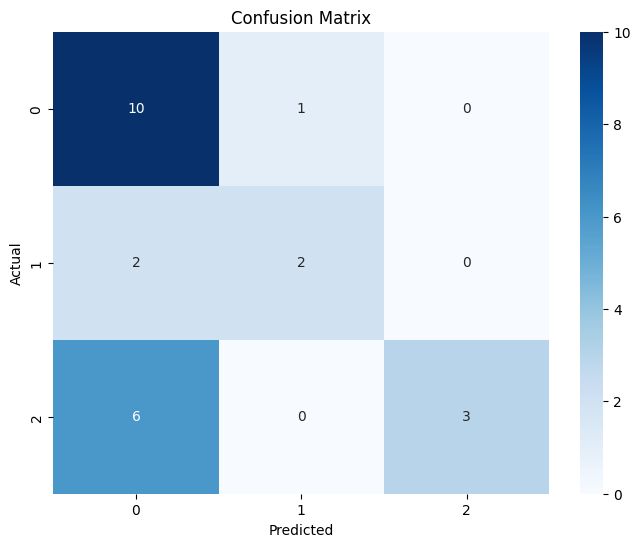

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.91      0.69        11
           1       0.67      0.50      0.57         4
           2       1.00      0.33      0.50         9

    accuracy                           0.62        24
   macro avg       0.74      0.58      0.59        24
weighted avg       0.74      0.62      0.60        24



In [15]:
feature_names = X.columns

coef_df = pd.DataFrame(
    model.coef_,
    columns=feature_names
)

coef_df

,Tahun Lulus,Rumpun Jurusan,Jenjang Pendidikan,Kategori IPK,Lama Masa Studi,Pernah Magang,Memiliki Sertifikasi,Memiliki Prestasi,Aktif Organisasi,Jabatan Organisasi,Tingkat Keaktifan Organisasi (1-5),Jumlah Organisasi
0,-0.142743,-0.006492,0.219016,0.007304,-0.030882,0.450867,0.015748,0.079372,0.033317,0.144136,0.622910,-0.288367
1,-0.087613,0.072949,-0.732345,-1.010750,-0.133900,-1.553544,-1.212822,-0.721353,-0.846910,-0.430700,-0.807803,-0.625592
2,-0.064002,-0.166266,0.400850,0.824926,0.133884,1.720712,1.108701,0.271037,0.950939,-0.003127,0.428064,1.077594
3,0.294357,0.099810,0.112479,0.178520,0.030897,-0.618035,0.088373,0.370945,-0.137346,0.289691,-0.243170,-0.163635


In [16]:
coef_mean = np.mean(np.abs(model.coef_), axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': coef_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
5,Pernah Magang,1.085789
6,Memiliki Sertifikasi,0.606411
11,Jumlah Organisasi,0.538797
10,Tingkat Keaktifan Organisasi (1-5),0.525487
3,Kategori IPK,0.505375
8,Aktif Organisasi,0.492128
2,Jenjang Pendidikan,0.366172
7,Memiliki Prestasi,0.360677
9,Jabatan Organisasi,0.216914
0,Tahun Lulus,0.147179


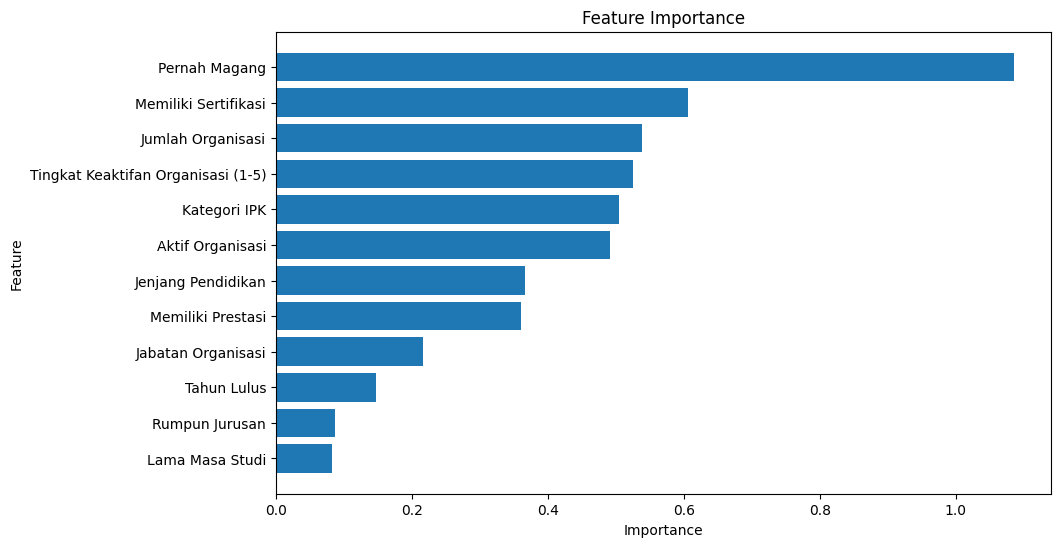

In [17]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()